In [82]:
# Final Project
# Date: 3/31/2026

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.colors as mcolors
import numpy as np
import geopandas as gpd

In [37]:
# Load from CSV file
inspectionsData = pd.read_csv('inspectionsData.csv')

C:\Users\celes\AppData\Local\Temp\ipykernel_18112\1165627864.py:2: DtypeWarning: Columns (0: zip) have mixed types. Specify dtype option on import or set low_memory=False.
  inspectionsData = pd.read_csv('inspectionsData.csv')


In [38]:
# QUESTION: To what extent have Boston safety inspection outcomes changed over 
    # time in terms of amount and severity, and are certain neighborhoods 
    # improving or worsening over the past 20 years?

# ==========================================
# STEP 1: DATA EXPLORATION
# ==========================================

print(inspectionsData.columns)
# ['businessname', 'dbaname', 'legalowner', 'namelast', 'namefirst',
#       'licenseno', 'issdttm', 'expdttm', 'licstatus', 'licensecat',      
#       'descript', 'result', 'resultdttm', 'violation', 'viol_level',     
#       'violdesc', 'violdttm', 'viol_status', 'status_date', 'comments',  
#       'address', 'city', 'state', 'zip', 'property_id', 'location']

print(inspectionsData.head())

# Look for inconsistent/disparities in variables
print(inspectionsData["city"].value_counts()) 
    # Clean the titles if they contain "/"
        # Ex: "FINANCIAL DISTRICT/" & "FINANCIAL DISTRICT"
    # Combine some of the cities where titles are off
        # Ex: "DOWNTOWN/FINANCIAL DISTRICT" & Above
print(inspectionsData["result"].value_counts()) 
    # Add "Fail" as a "HE_Fail" and "Pass" as "HE_Pass"

Index(['businessname', 'dbaname', 'legalowner', 'namelast', 'namefirst',
       'licenseno', 'issdttm', 'expdttm', 'licstatus', 'licensecat',
       'descript', 'result', 'resultdttm', 'violation', 'viol_level',
       'violdesc', 'violdttm', 'viol_status', 'status_date', 'comments',
       'address', 'city', 'state', 'zip', 'property_id', 'location'],
      dtype='str')
         businessname dbaname    legalowner         namelast  \
0  1000 Degrees Pizza     NaN  KHOSLA VIPAN  Pasquriello LLC   
1  1000 Degrees Pizza     NaN  KHOSLA VIPAN  Pasquriello LLC   
2  1000 Degrees Pizza     NaN  KHOSLA VIPAN  Pasquriello LLC   
3  1000 Degrees Pizza     NaN  KHOSLA VIPAN  Pasquriello LLC   
4  1000 Degrees Pizza     NaN  KHOSLA VIPAN  Pasquriello LLC   

              namefirst  licenseno                 issdttm  \
0  Kenneth Pasquariello     313440  2017-08-14 12:49:37+00   
1  Kenneth Pasquariello     313440  2017-08-14 12:49:37+00   
2  Kenneth Pasquariello     313440  2017-08-14 12:49:37

In [39]:
# ==========================================
# STEP 2: DATA CLEANING
# ==========================================

# All of the steps below are simply a reflection/mirror of what is
    # explained in the analysis plan submitted in the write up.

# ── 1. Parse dates & extract year ─────────────────────────────────────────────
# Decision: If values un-parsable, make them NaT
inspectionsData['resultdttm'] = pd.to_datetime(inspectionsData['resultdttm'], errors='coerce')

# Extract year as integer (Int64 first to handle NaT safely, then convert to int)
inspectionsData = inspectionsData.dropna(subset=['resultdttm'])
inspectionsData['year'] = inspectionsData['resultdttm'].dt.year.astype(int) # Cause it was in 2025.0 format

print("Rows with missing resultdttm after parsing:", inspectionsData['resultdttm'].isna().sum())
# No missing rows, no 0s


Rows with missing resultdttm after parsing: 0


In [40]:
# ── 2. Explore missing values ──────────────────────────────────────────────────

# Show count and % of missing values for every column = Thank you Claude for this code
missing = pd.DataFrame({
    'missing_count': inspectionsData.isna().sum(),
    'missing_pct':   inspectionsData.isna().sum() / len(inspectionsData) * 100
}).sort_values('missing_pct', ascending=False)

print(missing)

# Decisions per column:
# - viol_level, violdesc, viol_status: missing = no violation on that row (Pass rows) 
# XXXX^
# - zip: small number missing for zip, but none for city -> so no major problem

              missing_count  missing_pct
dbaname              845983    99.061705
status_date          494707    57.928491
namefirst            364145    42.640129
legalowner           296638    34.735292
property_id          152588    17.867531
location              76148     8.916669
comments              69299     8.114675
violdesc              52171     6.109045
violdttm              45847     5.368526
viol_level            45845     5.368292
violation             45845     5.368292
viol_status           45845     5.368292
state                  1122     0.131382
issdttm                 759     0.088876
expdttm                 630     0.073771
zip                     603     0.070609
address                 180     0.021077
namelast                  0     0.000000
businessname              0     0.000000
descript                  0     0.000000
licensecat                0     0.000000
licstatus                 0     0.000000
licenseno                 0     0.000000
resultdttm      

In [41]:
# ── 3. Add numeric severity column (on violation-level data, BEFORE grouping) ──

# Keeping the original viol_level column intact and creating a new numeric one
# * = 1 (low severity), ** = 2 (medium), *** = 3 (high)
inspectionsData['viol_level_num'] = inspectionsData['viol_level'].replace({'*': 1, '**': 2, '***': 3})

# Any value that was not *, **, or *** (including NaN from Pass rows) stays as NaN
inspectionsData['viol_level_num'] = pd.to_numeric(inspectionsData['viol_level_num'], errors='coerce')

print("viol_level_num sample:\n", inspectionsData['viol_level_num'].value_counts(dropna=False))
# XXX 1919.0         1 ??

viol_level_num sample:
 viol_level_num
1.0       569871
3.0       124634
2.0       107319
NaN        52171
1919.0         1
Name: count, dtype: int64


In [42]:
# ── 4. Reconstruct to a inspection-level data ──────────────────────────────────────

# Each row is one violation aka group by business + inspection date to get one row per inspection
inspection_df = (
    inspectionsData.groupby(['businessname', 'resultdttm', 'city', 'zip', 'year', 'result', 'descript'])
    .agg(
        num_violations = ('violation', 'count')   # count violations per inspection, add in new col
    )
    .reset_index()
)

print(inspection_df.shape)
print(inspection_df.head()) # Looks goooood! 

(198820, 8)
                               businessname                resultdttm  \
0                       10-Eleven Food Shop 2025-10-17 14:39:37+00:00   
1                       10-Eleven Food Shop 2025-10-21 19:14:28+00:00   
2  100 Federal Market & Barista- 10th Floor 2023-08-23 12:28:50+00:00   
3  100 Federal Market & Barista- 10th Floor 2024-03-11 16:18:18+00:00   
4  100 Federal Market & Barista- 10th Floor 2025-09-30 14:45:23+00:00   

         city    zip  year   result           descript  num_violations  
0  ROSLINDALE  02131  2025  HE_Fail        Retail Food               5  
1  ROSLINDALE  02131  2025  HE_Pass        Retail Food               5  
2      BOSTON  02110  2023  HE_Pass  Eating & Drinking               0  
3      BOSTON  02110  2024  HE_Pass  Eating & Drinking               0  
4      BOSTON  02110  2025  HE_Pass  Eating & Drinking               0  


In [43]:
# ── Added City Cleaning as seen problematic from Exploration ──────────────────────────────────

print("\nCity levels BEFORE cleaning:\n", inspection_df['city'].value_counts())

# Strip whitespace and uppercase everything for consistency since we cannot see those always (just in case)
inspection_df['city'] = inspection_df['city'].str.strip().str.upper()

# Remove trailing slashes (like the example we found above "FINANCIAL DISTRICT/" → "FINANCIAL DISTRICT")
inspection_df['city'] = inspection_df['city'].str.rstrip('/')

# Manually combine neighborhood names that refer to the same place
city_map = {
    'DOWNTOWN/FINANCIAL DISTRICT': 'FINANCIAL DISTRICT',
    'DOWNTOWN': 'FINANCIAL DISTRICT',
    'ROXBURY/BOSTON': 'ROXBURY',
    'BOSTON/WEST END': 'WEST END',
    'BOSTON/CHINATOWN': 'CHINATOWN',
    'DORCHESTER CENTER': 'DORCHESTER',
    'ROXBURY CROSSIN':   'ROXBURY',
}
inspection_df['city'] = inspection_df['city'].replace(city_map)

print("\nCity levels AFTER cleaning:\n", inspection_df['city'].value_counts())


City levels BEFORE cleaning:
 city
BOSTON                         96384
DORCHESTER                     23993
ROXBURY                        13728
EAST BOSTON                    12988
JAMAICA PLAIN                   7522
ALLSTON                         7497
BRIGHTON                        7228
SOUTH BOSTON                    6224
ROSLINDALE                      5164
WEST ROXBURY                    4502
HYDE PARK                       3587
MATTAPAN                        3268
CHARLESTOWN                     3217
MISSION HILL                    2735
CHESTNUT HILL                    165
SOUTH BOSTON/                     91
FINANCIAL DISTRICT                90
MISSION HILL/                     65
CHARLESTOWN/                      49
ROSLINDALE/                       46
FENWAY                            43
DOWNTOWN/FINANCIAL DISTRICT       31
BRIGHTON/                         25
MATTAPAN/                         25
FINANCIAL DISTRICT/               23
ROXBURY/BOSTON                    20
FE

In [44]:
# ── 5. Clean and standardize the result column ────────────────────────────────

print("\nResult levels BEFORE cleaning:\n", inspection_df['result'].value_counts(dropna=False))

# Combine "Pass"/"Fail" with the "HE_Pass"/"HE_Fail" entries — same outcome, different recording
inspection_df['result'] = inspection_df['result'].replace({
    'Pass': 'HE_Pass',
    'Fail': 'HE_Fail',
})

# Drop HE_Filed, HE_NotReq, HE_OutBus, etc. — we only care about Pass/Fail outcomes
analysis_df = inspection_df[inspection_df['result'].isin(['HE_Pass', 'HE_Fail'])].copy()

print("\nResult levels AFTER cleaning:\n", analysis_df['result'].value_counts(dropna=False))

# Binary fail indicator: 1 = fail, 0 = pass — useful for computing fail rates later
analysis_df['failed'] = (analysis_df['result'] == 'HE_Fail').astype(int)

print("\nRows kept after result filter:", len(analysis_df))
print("Overall fail rate:", analysis_df['failed'].mean().round(3))


Result levels BEFORE cleaning:
 result
HE_Pass       86487
HE_Fail       61940
HE_Filed      24926
HE_NotReq      9927
HE_FailExt     9496
HE_Hearing     3223
HE_OutBus      1051
HE_TSOP         817
HE_VolClos      476
Pass            223
HE_Closure      115
HE_Misc          76
Fail             25
HE_FAILNOR       21
DATAERR           8
HE_Hold           5
Closed            2
NoViol            1
Failed            1
Name: count, dtype: int64

Result levels AFTER cleaning:
 result
HE_Pass    86710
HE_Fail    61965
Name: count, dtype: int64

Rows kept after result filter: 148675
Overall fail rate: 0.417


In [45]:
# Final look/Check 

print(analysis_df.info())
print(analysis_df.head())

<class 'pandas.DataFrame'>
Index: 148675 entries, 0 to 198818
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   businessname    148675 non-null  str                
 1   resultdttm      148675 non-null  datetime64[us, UTC]
 2   city            148675 non-null  str                
 3   zip             148675 non-null  object             
 4   year            148675 non-null  int64              
 5   result          148675 non-null  str                
 6   descript        148675 non-null  str                
 7   num_violations  148675 non-null  int64              
 8   failed          148675 non-null  int64              
dtypes: datetime64[us, UTC](1), int64(3), object(1), str(4)
memory usage: 11.3+ MB
None
                               businessname                resultdttm  \
0                       10-Eleven Food Shop 2025-10-17 14:39:37+00:00   
1                       10-Eleven 

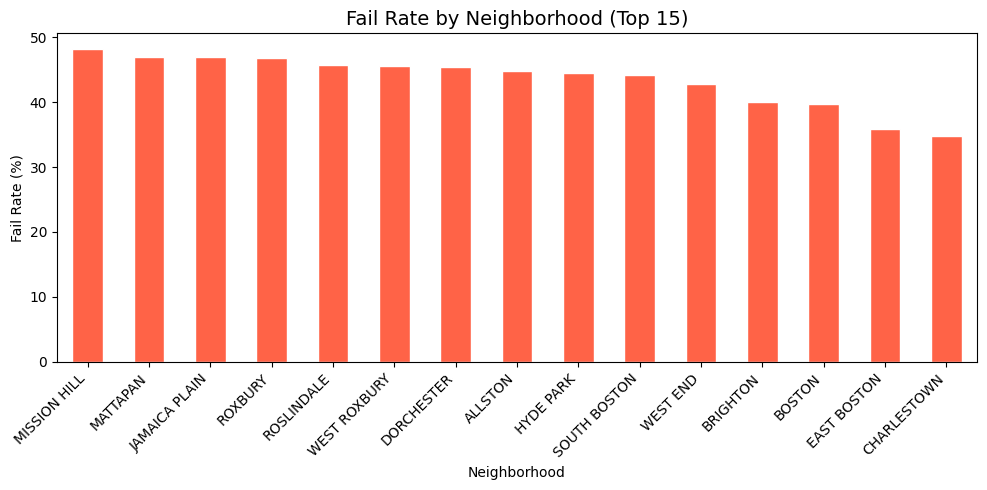

In [46]:
fail_by_city = (
    analysis_df.groupby('city')['failed'].mean()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 5))
fail_by_city.mul(100).plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
ax.set_title('Fail Rate by Neighborhood (Top 15)', fontsize=14)
ax.set_xlabel('Neighborhood')
ax.set_ylabel('Fail Rate (%)')
ax.set_xticklabels(fail_by_city.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

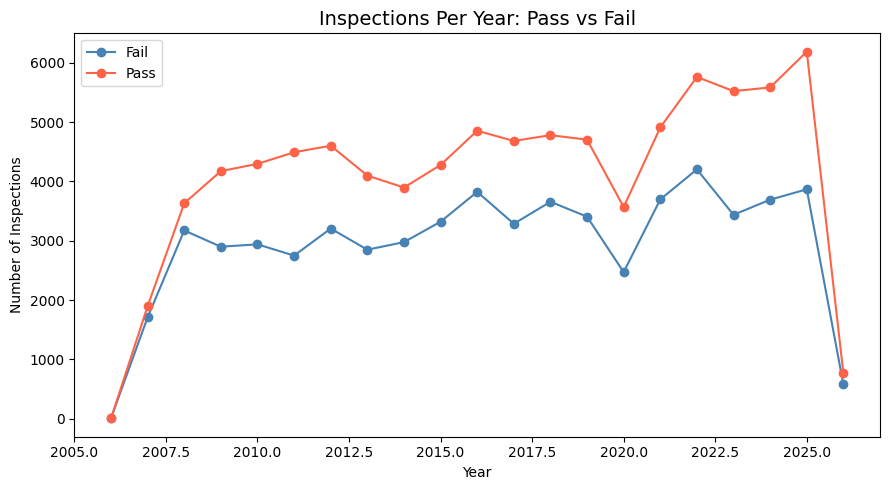

In [47]:
inspections_by_year = analysis_df.groupby(['year', 'result']).size().unstack()

fig, ax = plt.subplots(figsize=(9, 5))
inspections_by_year.plot(kind='line', ax=ax, marker='o', color=['steelblue', 'tomato'])
ax.set_title('Inspections Per Year: Pass vs Fail', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Inspections')
ax.legend(['Fail', 'Pass'])
plt.tight_layout()
plt.show()

C:\Users\celes\AppData\Local\Temp\ipykernel_18112\1184384868.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


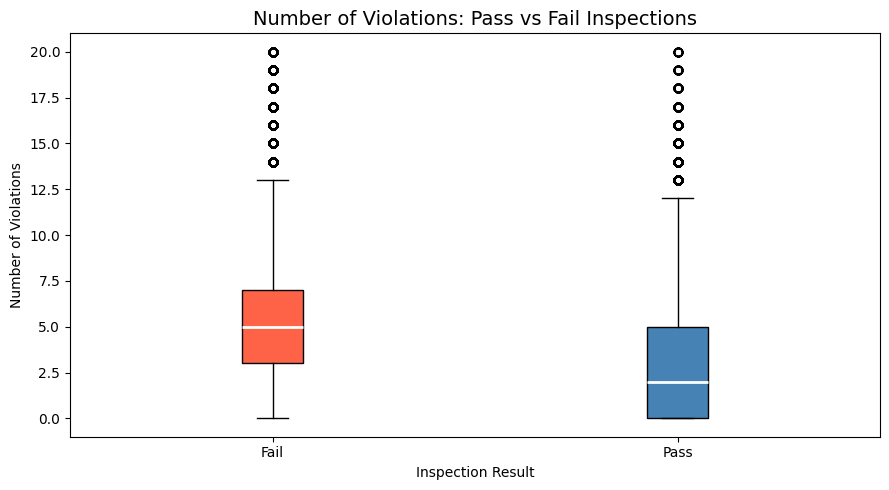

In [48]:
pass_viols = analysis_df[analysis_df['result'] == 'HE_Pass']['num_violations']
fail_viols = analysis_df[analysis_df['result'] == 'HE_Fail']['num_violations']

# Cap outliers for readability
pass_viols = pass_viols[pass_viols <= 20]
fail_viols = fail_viols[fail_viols <= 20]

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(
    [fail_viols, pass_viols],
    labels=['Fail', 'Pass'],
    patch_artist=True,
    boxprops=dict(facecolor='tomato'),
    medianprops=dict(color='white', linewidth=2)
)

# Color the Pass box differently
ax.patches[1].set_facecolor('steelblue')

ax.set_title('Number of Violations: Pass vs Fail Inspections', fontsize=14)
ax.set_xlabel('Inspection Result')
ax.set_ylabel('Number of Violations')
plt.tight_layout()
plt.show()

In [49]:
# A few to start with^

In [50]:
# ==========================================
# STEP 3: TREND ANALYSIS = VOLUME
# ==========================================

# ── 1. Yearly inspection and violation counts ──────────────────────────────────
yearly_counts = analysis_df.groupby('year').agg(
    total_inspections = ('businessname', 'count'),
    total_violations  = ('num_violations', 'sum')
).reset_index()

print(yearly_counts)

    year  total_inspections  total_violations
0   2006                 14                16
1   2007               3608             19568
2   2008               6807             35452
3   2009               7075             31660
4   2010               7237             28974
5   2011               7243             26733
6   2012               7809             35668
7   2013               6949             30882
8   2014               6875             32831
9   2015               7601             33773
10  2016               8681             38991
11  2017               7970             32240
12  2018               8439             38339
13  2019               8112             33061
14  2020               6040             22827
15  2021               8609             32119
16  2022               9967             37110
17  2023               8961             28656
18  2024               9279             31088
19  2025              10057             31052
20  2026               1342       

In [51]:

# ── 2. Compute citywide fail rate per year ─────────────────────────────────────
# fail rate = inspections with at least 1 violation / total inspections
yearly_fail = analysis_df.groupby('year').agg(
    total_inspections = ('failed', 'count'),
    total_fails       = ('failed', 'sum')
).reset_index()

yearly_fail['fail_rate'] = yearly_fail['total_fails'] / yearly_fail['total_inspections']

print(yearly_fail)

    year  total_inspections  total_fails  fail_rate
0   2006                 14            9   0.642857
1   2007               3608         1710   0.473947
2   2008               6807         3174   0.466285
3   2009               7075         2900   0.409894
4   2010               7237         2940   0.406246
5   2011               7243         2750   0.379677
6   2012               7809         3206   0.410552
7   2013               6949         2850   0.410131
8   2014               6875         2977   0.433018
9   2015               7601         3322   0.437048
10  2016               8681         3825   0.440617
11  2017               7970         3287   0.412422
12  2018               8439         3658   0.433464
13  2019               8112         3407   0.419995
14  2020               6040         2471   0.409106
15  2021               8609         3698   0.429550
16  2022               9967         4204   0.421792
17  2023               8961         3438   0.383663
18  2024    

In [52]:
# ── 3. Normalize by neighborhood size ─────────────────────────────────────────
# Fail rate per neighborhood per year (proportion, not raw count)
neighborhood_fail = analysis_df.groupby(['year', 'city']).agg(
    total_inspections = ('failed', 'count'),
    total_fails       = ('failed', 'sum')
).reset_index()

neighborhood_fail['fail_rate'] = neighborhood_fail['total_fails'] / neighborhood_fail['total_inspections']

print(neighborhood_fail.head(20))

# Like predicted some have extreme noisy results because only few inspections.


    year           city  total_inspections  total_fails  fail_rate
0   2006         BOSTON                  5            3   0.600000
1   2006       BRIGHTON                  1            1   1.000000
2   2006    CHARLESTOWN                  1            1   1.000000
3   2006     DORCHESTER                  1            1   1.000000
4   2006     ROSLINDALE                  1            0   0.000000
5   2006   SOUTH BOSTON                  4            2   0.500000
6   2006   WEST ROXBURY                  1            1   1.000000
7   2007        ALLSTON                258          133   0.515504
8   2007         BOSTON               1709          836   0.489175
9   2007       BRIGHTON                201           93   0.462687
10  2007    CHARLESTOWN                 78           39   0.500000
11  2007  CHESTNUT HILL                  6            1   0.166667
12  2007     DORCHESTER                385          187   0.485714
13  2007    EAST BOSTON                212           84   0.39

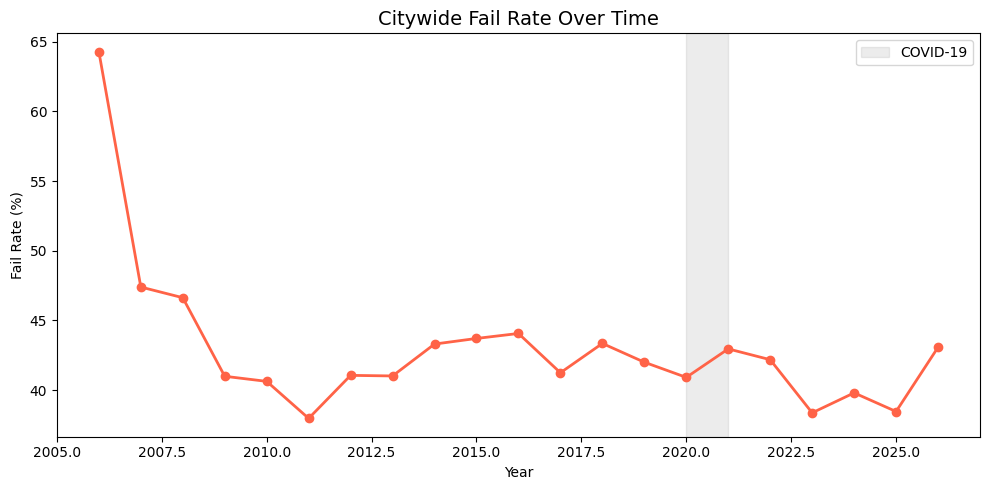

In [53]:
# ── 4. Visualize citywide fail rate over time ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_fail['year'], yearly_fail['fail_rate'] * 100, 
        marker='o', color='tomato', linewidth=2)
ax.axvspan(2020, 2021, alpha=0.15, color='gray', label='COVID-19')
ax.set_title('Citywide Fail Rate Over Time', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Fail Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

In [54]:
# ==========================================
# STEP 4: TREND ANALYSIS = SEVERITY
# ==========================================

# We need avg severity per inspection, so go back to violation-level data
# and compute mean viol_level_num per inspection, then merge onto analysis_df

# Check dtypes to diagnose
print(inspectionsData['resultdttm'].dtype)
print(analysis_df['resultdttm'].dtype)

# Strip timezone from both before merging
inspectionsData['resultdttm'] = inspectionsData['resultdttm'].dt.tz_localize(None)
analysis_df['resultdttm'] = analysis_df['resultdttm'].dt.tz_localize(None)

# ── 1. Compute severity stats per inspection ───────────────────────────────────
viol_data = inspectionsData[['businessname', 'resultdttm', 'viol_level_num']].copy()

severity_per_inspection = (
    viol_data.groupby(['businessname', 'resultdttm'])['viol_level_num']
    .agg(avg_severity='mean')
    .reset_index()
)

for val, col in [(1, 'count_low'), (2, 'count_med'), (3, 'count_high')]:
    tier = (viol_data['viol_level_num'] == val).groupby(
        [viol_data['businessname'], viol_data['resultdttm']]
    ).sum().reset_index(name=col)
    severity_per_inspection = severity_per_inspection.merge(
        tier, on=['businessname', 'resultdttm'], how='left'
    )

# ── 2. Merge onto analysis_df ──────────────────────────────────────────────────
analysis_df = analysis_df.merge(severity_per_inspection,
                                 on=['businessname', 'resultdttm'],
                                 how='left')

print(analysis_df[['businessname', 'resultdttm', 'avg_severity',
                    'count_low', 'count_med', 'count_high']].head(10))

datetime64[us, UTC]
datetime64[us, UTC]
                               businessname          resultdttm  avg_severity  \
0                       10-Eleven Food Shop 2025-10-17 14:39:37           1.2   
1                       10-Eleven Food Shop 2025-10-21 19:14:28           1.2   
2  100 Federal Market & Barista- 10th Floor 2023-08-23 12:28:50           NaN   
3  100 Federal Market & Barista- 10th Floor 2024-03-11 16:18:18           NaN   
4  100 Federal Market & Barista- 10th Floor 2025-09-30 14:45:23           NaN   
5  100 Federal Market & Barista- 11th Floor 2022-03-10 16:33:56           NaN   
6  100 Federal Market & Barista- 11th Floor 2022-06-16 17:44:19           NaN   
7  100 Federal Market & Barista- 11th Floor 2022-10-21 15:41:03           NaN   
8  100 Federal Market & Barista- 11th Floor 2023-03-08 17:33:56           NaN   
9  100 Federal Market & Barista- 11th Floor 2023-09-07 15:46:04           NaN   

   count_low  count_med  count_high  
0          4          1       

In [55]:
# ── 3. Yearly average severity ─────────────────────────────────────────────────
yearly_severity = analysis_df.groupby('year').agg(
    mean_severity = ('avg_severity', 'mean'),
    mean_low      = ('count_low', 'mean'),
    mean_med      = ('count_med', 'mean'),
    mean_high     = ('count_high', 'mean')
).reset_index()

print(yearly_severity)

    year  mean_severity  mean_low  mean_med  mean_high
0   2006       1.414815  0.857143  0.000000   0.285714
1   2007       1.405462  4.119457  0.395787   0.910477
2   2008       1.428732  3.954899  0.323491   0.929778
3   2009       1.412128  3.434205  0.304311   0.736254
4   2010       1.422349  3.045323  0.246373   0.711897
5   2011       1.516945  2.740163  0.247687   0.703024
6   2012       1.493051  3.398258  0.330004   0.839288
7   2013       1.453744  3.388113  0.293855   0.762124
8   2014       1.474500  3.605964  0.297891   0.871564
9   2015       1.492923  3.291146  0.299434   0.852651
10  2016       1.498366  3.351918  0.284760   0.854855
11  2017       1.503935  2.997867  0.274906   0.772396
12  2018       1.557931  3.271833  0.324683   0.946558
13  2019       1.549625  2.746795  0.699951   0.627342
14  2020       1.520585  2.300331  1.108609   0.369868
15  2021       1.534047  2.169125  1.030085   0.402950
16  2022       1.532264  2.186415  1.051871   0.401625
17  2023  

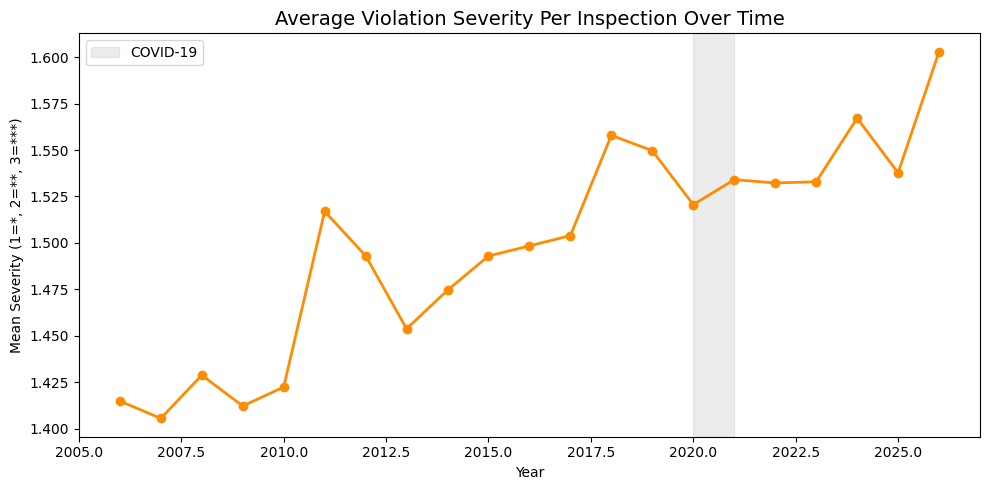

In [56]:
# ── 4. Visualize average severity over time ────────────────────────────────────

# This for a graph overtime of overall average 
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_severity['year'], yearly_severity['mean_severity'],
        marker='o', color='darkorange', linewidth=2)
ax.axvspan(2020, 2021, alpha=0.15, color='gray', label='COVID-19')
ax.set_title('Average Violation Severity Per Inspection Over Time', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Mean Severity (1=*, 2=**, 3=***)')
ax.legend()
plt.tight_layout()
plt.show()



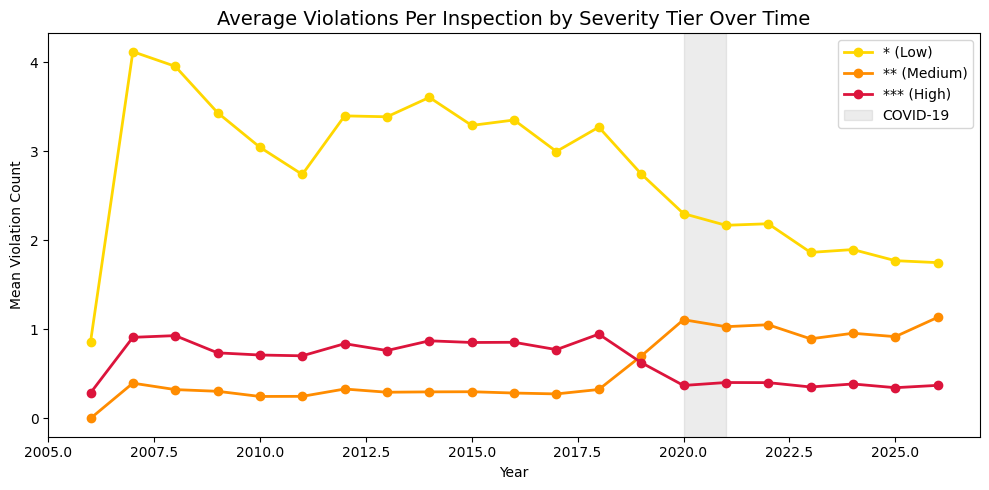

In [57]:
# ── 5. Visualize breakdown by severity tier over time ─────────────────────────

# And this for a graph that shows the * vs ** vs ***
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_severity['year'], yearly_severity['mean_low'], 
        marker='o', color='gold', linewidth=2, label='* (Low)')
ax.plot(yearly_severity['year'], yearly_severity['mean_med'], 
        marker='o', color='darkorange', linewidth=2, label='** (Medium)')
ax.plot(yearly_severity['year'], yearly_severity['mean_high'], 
        marker='o', color='crimson', linewidth=2, label='*** (High)')
ax.axvspan(2020, 2021, alpha=0.15, color='gray', label='COVID-19')
ax.set_title('Average Violations Per Inspection by Severity Tier Over Time', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Mean Violation Count')
ax.legend()
plt.tight_layout()
plt.show()

In [58]:
# ==========================================
# STEP 5: TREND ANALYSIS = NEIGHBORHOODS
# ==========================================

# ── 1. Filter to neighborhoods with enough data ────────────────────────────────
# Neighborhoods with very few inspections give noisy estimates
# Keep only neighborhoods with at least 50 inspections total across all years
city_counts = analysis_df.groupby('city')['failed'].count()
valid_cities = city_counts[city_counts >= 50].index
neighborhood_df = neighborhood_fail[neighborhood_fail['city'].isin(valid_cities)].copy()

print("Neighborhoods kept:", neighborhood_df['city'].nunique())

Neighborhoods kept: 16


In [59]:
# ── 2. Compute change score per neighborhood ───────────────────────────────────
# Compare average fail rate of first 3 years vs last 3 years
# (more robust than just comparing single earliest vs latest year)

early_years = sorted(analysis_df['year'].unique())[:3]
late_years  = sorted(analysis_df['year'].unique())[-3:]

early = neighborhood_df[neighborhood_df['year'].isin(early_years)].groupby('city')['fail_rate'].mean()
late  = neighborhood_df[neighborhood_df['year'].isin(late_years)].groupby('city')['fail_rate'].mean()

change_df = pd.DataFrame({
    'early_fail_rate': early,
    'late_fail_rate':  late
}).dropna()

change_df['change'] = change_df['late_fail_rate'] - change_df['early_fail_rate']
change_df = change_df.sort_values('change')

print(change_df)

                    early_fail_rate  late_fail_rate    change
city                                                         
BRIGHTON                   0.658558        0.378931 -0.279627
CHARLESTOWN                0.580000        0.337835 -0.242165
DORCHESTER                 0.647720        0.447460 -0.200261
FINANCIAL DISTRICT         0.400000        0.236111 -0.163889
WEST ROXBURY               0.583460        0.434812 -0.148648
HYDE PARK                  0.557676        0.412922 -0.144754
SOUTH BOSTON               0.511747        0.385445 -0.126302
BOSTON                     0.518369        0.394379 -0.123990
EAST BOSTON                0.390045        0.283450 -0.106594
ALLSTON                    0.536488        0.432573 -0.103914
MATTAPAN                   0.506279        0.448715 -0.057563
ROXBURY                    0.488217        0.460992 -0.027225
JAMAICA PLAIN              0.423611        0.455938  0.032326
MISSION HILL               0.428758        0.468435  0.039677
ROSLINDA

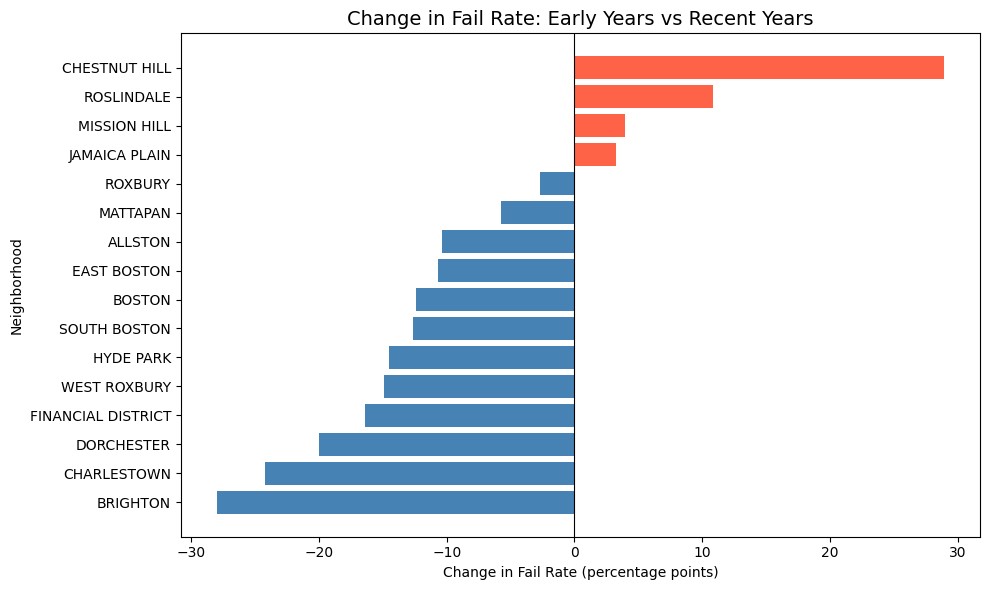

In [60]:
# ── 3. Bar chart of improvement vs worsening neighborhoods ────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['steelblue' if x < 0 else 'tomato' for x in change_df['change']]
ax.barh(change_df.index, change_df['change'] * 100, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Change in Fail Rate: Early Years vs Recent Years', fontsize=14)
ax.set_xlabel('Change in Fail Rate (percentage points)')
ax.set_ylabel('Neighborhood')
plt.tight_layout()
plt.show()

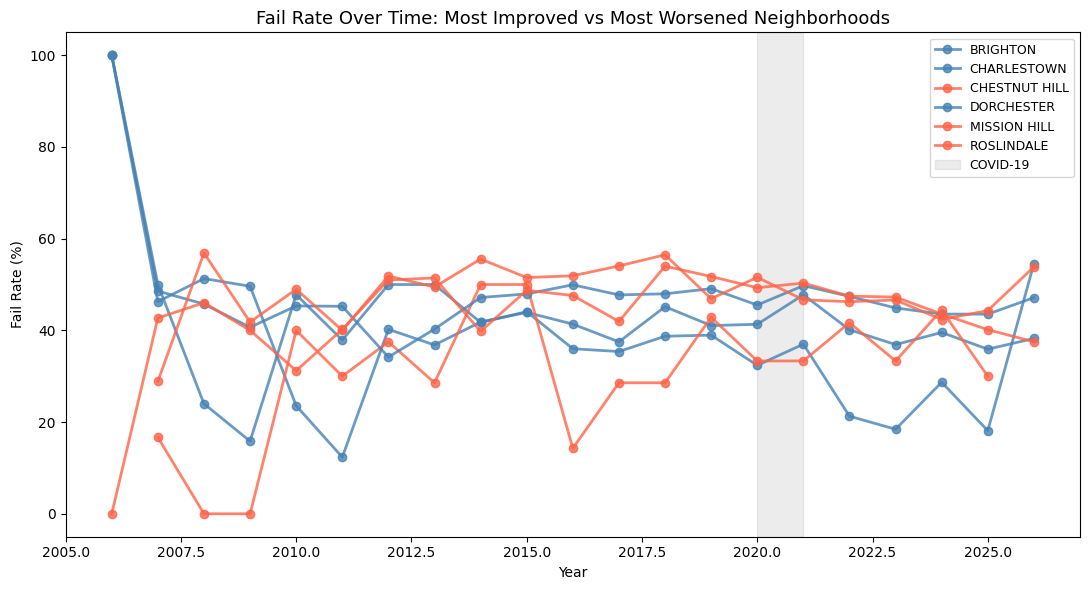

In [61]:
# NOT GREAT GRAPH 

# ── 4. Line chart: top 6 most interesting neighborhoods over time ──────────────
# Pick the 3 most improved + 3 most worsened
top_improved  = change_df.head(3).index.tolist()
top_worsened  = change_df.tail(3).index.tolist()
focus_cities  = top_improved + top_worsened

focus_df = neighborhood_df[neighborhood_df['city'].isin(focus_cities)]

fig, ax = plt.subplots(figsize=(11, 6))
for city, grp in focus_df.groupby('city'):
    grp = grp.sort_values('year')
    color = 'steelblue' if city in top_improved else 'tomato'
    ax.plot(grp['year'], grp['fail_rate'] * 100, marker='o', linewidth=2,
            label=city, color=color, alpha=0.8)

ax.axvspan(2020, 2021, alpha=0.15, color='gray', label='COVID-19')
ax.set_title('Fail Rate Over Time: Most Improved vs Most Worsened Neighborhoods', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Fail Rate (%)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

In [62]:
# ==========================================
# STEP 6: MODEL = LINEAR REGRESSION
# ==========================================

# ── 1. Citywide: fail rate ~ year ─────────────────────────────────────────────

slope, intercept, r_value, p_value, std_err = stats.linregress(
    yearly_fail['year'], yearly_fail['fail_rate']
)

print("=== Citywide Fail Rate ~ Year ===")
print(f"Slope:     {slope:.5f}  (fail rate change per year)")
print(f"Intercept: {intercept:.3f}")
print(f"R²:        {r_value**2:.3f}")
print(f"P-value:   {p_value:.4f}")

=== Citywide Fail Rate ~ Year ===
Slope:     -0.00430  (fail rate change per year)
Intercept: 9.104
R²:        0.241
P-value:   0.0239


In [63]:
# ── 2. Citywide: severity ~ year ──────────────────────────────────────────────

slope_sev, intercept_sev, r_sev, p_sev, se_sev = stats.linregress(
    yearly_severity['year'], yearly_severity['mean_severity']
)

print("=== Citywide Severity ~ Year ===")
print(f"Slope:     {slope_sev:.5f}  (severity change per year)")
print(f"Intercept: {intercept_sev:.3f}")
print(f"R²:        {r_sev**2:.3f}")
print(f"P-value:   {p_sev:.4f}")

=== Citywide Severity ~ Year ===
Slope:     0.00824  (severity change per year)
Intercept: -15.116
R²:        0.815
P-value:   0.0000


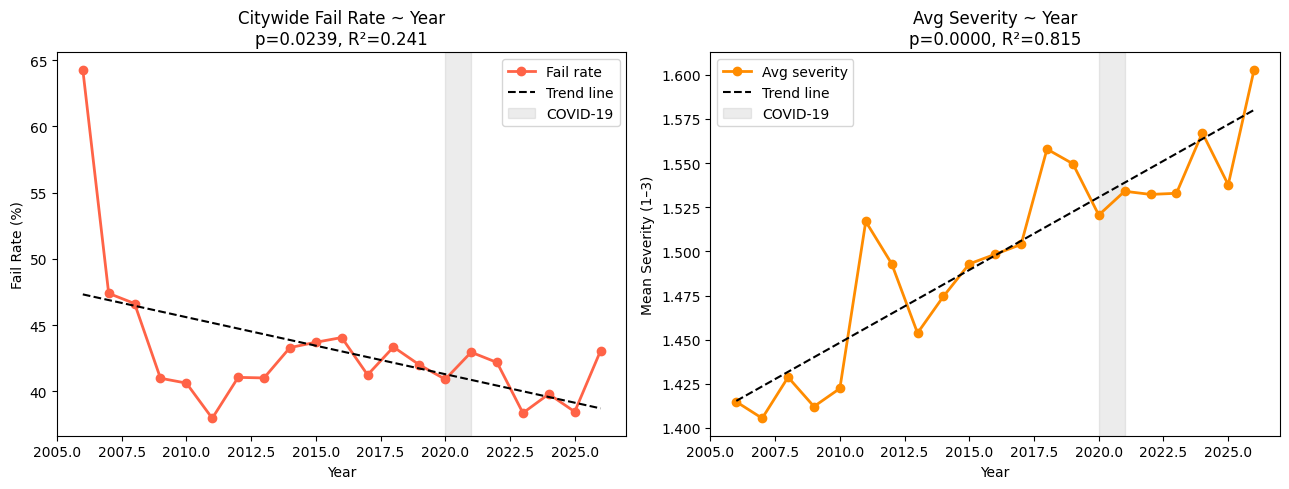

Fail rate slope: -0.00430 per year (-0.4302 percentage points/year)
Severity slope:  0.00824 per year


In [85]:
# ── 3. Visualize both regressions ─────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Fail rate
years = yearly_fail['year']
ax1.plot(years, yearly_fail['fail_rate'] * 100, marker='o', color='tomato', linewidth=2, label='Fail rate')
ax1.plot(years, (intercept + slope * years) * 100, '--', color='black', linewidth=1.5, label='Trend line')
ax1.axvspan(2020, 2021, alpha=0.15, color='gray', label='COVID-19')
ax1.set_title(f'Citywide Fail Rate ~ Year\np={p_value:.4f}, R²={r_value**2:.3f}', fontsize=12)
ax1.set_xlabel('Year')
ax1.set_ylabel('Fail Rate (%)')
ax1.legend()

# Severity
years_sev = yearly_severity['year']
ax2.plot(years_sev, yearly_severity['mean_severity'], marker='o', color='darkorange', linewidth=2, label='Avg severity')
ax2.plot(years_sev, intercept_sev + slope_sev * years_sev, '--', color='black', linewidth=1.5, label='Trend line')
ax2.axvspan(2020, 2021, alpha=0.15, color='gray', label='COVID-19')
ax2.set_title(f'Avg Severity ~ Year\np={p_sev:.4f}, R²={r_sev**2:.3f}', fontsize=12)
ax2.set_xlabel('Year')
ax2.set_ylabel('Mean Severity (1–3)')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Fail rate slope: {slope:.5f} per year ({slope*100:.4f} percentage points/year)")
print(f"Severity slope:  {slope_sev:.5f} per year")

In [65]:
# Major help from Claude for this one

# ── 4. Neighborhood-level regressions ─────────────────────────────────────────
# Run a separate regression for each neighborhood and save slope + p-value

results = []

for city, grp in neighborhood_df.groupby('city'):
    grp = grp.sort_values('year')
    if len(grp) < 5:       # need enough years to fit a line
        continue
    s, i, r, p, se = stats.linregress(grp['year'], grp['fail_rate'])
    results.append({
        'city':      city,
        'slope':     s,
        'r_squared': r**2,
        'p_value':   p
    })

results_df = pd.DataFrame(results).sort_values('slope')
print(results_df)

                  city     slope  r_squared   p_value
7   FINANCIAL DISTRICT -0.023608   0.404754  0.004534
3          CHARLESTOWN -0.012566   0.185698  0.051146
6          EAST BOSTON -0.009928   0.706206  0.000004
2             BRIGHTON -0.007795   0.094940  0.174188
5           DORCHESTER -0.005891   0.086389  0.195932
1               BOSTON -0.005077   0.339632  0.005563
15        WEST ROXBURY -0.003224   0.020353  0.537293
13             ROXBURY -0.002274   0.062553  0.287551
14        SOUTH BOSTON -0.001516   0.023129  0.510471
0              ALLSTON  0.000070   0.000026  0.982987
11        MISSION HILL  0.001875   0.027328  0.486110
9        JAMAICA PLAIN  0.003724   0.181979  0.060695
8            HYDE PARK  0.005030   0.056032  0.314986
10            MATTAPAN  0.005428   0.126536  0.123745
12          ROSLINDALE  0.007106   0.150563  0.082189
4        CHESTNUT HILL  0.012236   0.229328  0.038047


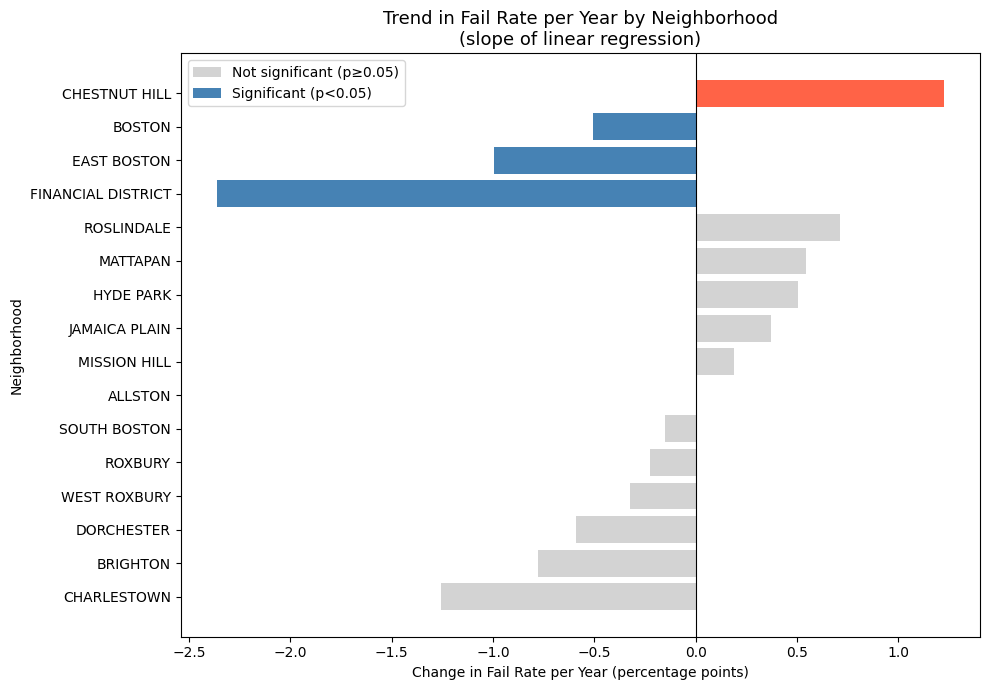

In [66]:
# ── 5. Visualize neighborhood slopes ──────────────────────────────────────────
# Highlight statistically significant ones (p < 0.05)

sig   = results_df[results_df['p_value'] < 0.05]
insig = results_df[results_df['p_value'] >= 0.05]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(insig['city'], insig['slope'] * 100, color='lightgray', label='Not significant (p≥0.05)')
ax.barh(sig['city'],   sig['slope']   * 100,
        color=['steelblue' if s < 0 else 'tomato' for s in sig['slope']],
        label='Significant (p<0.05)')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Trend in Fail Rate per Year by Neighborhood\n(slope of linear regression)', fontsize=13)
ax.set_xlabel('Change in Fail Rate per Year (percentage points)')
ax.set_ylabel('Neighborhood')
ax.legend()
plt.tight_layout()
plt.show()

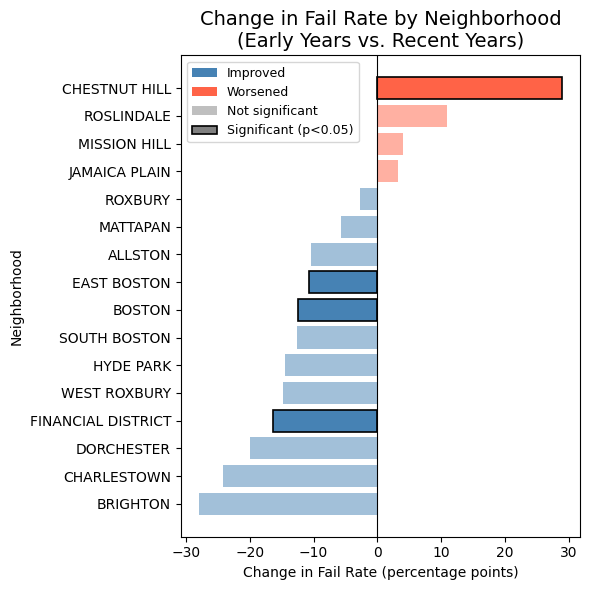

In [92]:
fig, ax = plt.subplots(figsize=(6, 6))

# All bars blue (improved) or red (worsened) — no gray
colors = ['steelblue' if x < 0 else 'tomato' for x in change_df['change']]
bars = ax.barh(change_df.index, change_df['change'] * 100, color=colors, alpha=0.5)

# You'll manually add a black border to significant ones after seeing the plot
# OR: pass in your sig list and it bolds automatically
sig_neighborhoods = results_df[results_df['p_value'] < 0.05]['city'].tolist()

for bar, city in zip(bars, change_df.index):
    if city in sig_neighborhoods:
        bar.set_alpha(1.0)        # full color = significant
        bar.set_edgecolor('black')
        bar.set_linewidth(1.2)
    # non-significant stay at alpha=0.5, no border

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Change in Fail Rate by Neighborhood\n(Early Years vs. Recent Years)', fontsize=14)
ax.set_xlabel('Change in Fail Rate (percentage points)')
ax.set_ylabel('Neighborhood')

# Add a simple legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Improved'),
    Patch(facecolor='tomato', label='Worsened'),
    Patch(facecolor='gray', alpha=0.5, label='Not significant'),
    Patch(facecolor='gray', edgecolor='black', linewidth=1.2, label='Significant (p<0.05)')
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

In [67]:
# Just to see try some other models:

# ── Multiple linear regression: fail rate ~ year + neighborhood + inspection type ──
import statsmodels.formula.api as smf

# descript and city need to be treated as categories (dummy variables)
analysis_df['city'] = analysis_df['city'].astype('category')
analysis_df['descript'] = analysis_df['descript'].astype('category')

model = smf.ols('failed ~ year + C(city) + C(descript)', data=analysis_df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 failed   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     82.65
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:06:23   Log-Likelihood:            -1.0483e+05
No. Observations:              148675   AIC:                         2.097e+05
Df Residuals:                  148650   BIC:                         2.100e+05
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [69]:
# ── 6. Predict 2026 and check ──────────────────────────────────────────────

# Train/test split — refits both models (fail rate and severity) on data up to 
    # 2025 only, then predicts 2026 and compares to actual 2026

# Split into training (up to 2025) and test (2026) 
train_fail = yearly_fail[yearly_fail['year'] <= 2025]
test_fail  = yearly_fail[yearly_fail['year'] == 2026]

train_sev = yearly_severity[yearly_severity['year'] <= 2025]
test_sev  = yearly_severity[yearly_severity['year'] == 2026]

# Refit models on training data only
slope_tr, intercept_tr, _, _, _ = stats.linregress(
    train_fail['year'], train_fail['fail_rate']
)
slope_sev_tr, intercept_sev_tr, _, _, _ = stats.linregress(
    train_sev['year'], train_sev['mean_severity']
)

# Predict 2026
pred_fail_2026 = intercept_tr + slope_tr * 2026
pred_sev_2026  = intercept_sev_tr + slope_sev_tr * 2026

print(f"\n=== 2026 Predictions (model trained on data up to 2025) ===")
print(f"Predicted fail rate 2026:     {pred_fail_2026 * 100:.2f}%")
print(f"Predicted avg severity 2026:  {pred_sev_2026:.4f}")



=== 2026 Predictions (model trained on data up to 2025) ===
Predicted fail rate 2026:     37.77%
Predicted avg severity 2026:  1.5752


In [70]:
# Compare to actual 2026 (if data exists) 
actual_sev_2026 = None
if len(test_fail) > 0:
    actual_fail_2026 = test_fail['fail_rate'].values[0]
    actual_sev_2026  = test_sev['mean_severity'].values[0] if len(test_sev) > 0 else None

    print(f"\nActual fail rate 2026:        {actual_fail_2026 * 100:.2f}%")
    print(f"Error (predicted - actual):   {(pred_fail_2026 - actual_fail_2026) * 100:.2f} pp")

    if actual_sev_2026 is not None:
        print(f"Actual avg severity 2026:     {actual_sev_2026:.4f}")
        print(f"Severity error:               {pred_sev_2026 - actual_sev_2026:.4f}")
else:
    print("\nNo 2026 data available to compare against.")


Actual fail rate 2026:        43.07%
Error (predicted - actual):   -5.30 pp
Actual avg severity 2026:     1.6030
Severity error:               -0.0278



=== 2027 Forecast (model trained on ALL data) ===
Predicted fail rate 2027:     38.28%
Predicted avg severity 2027:  1.5884


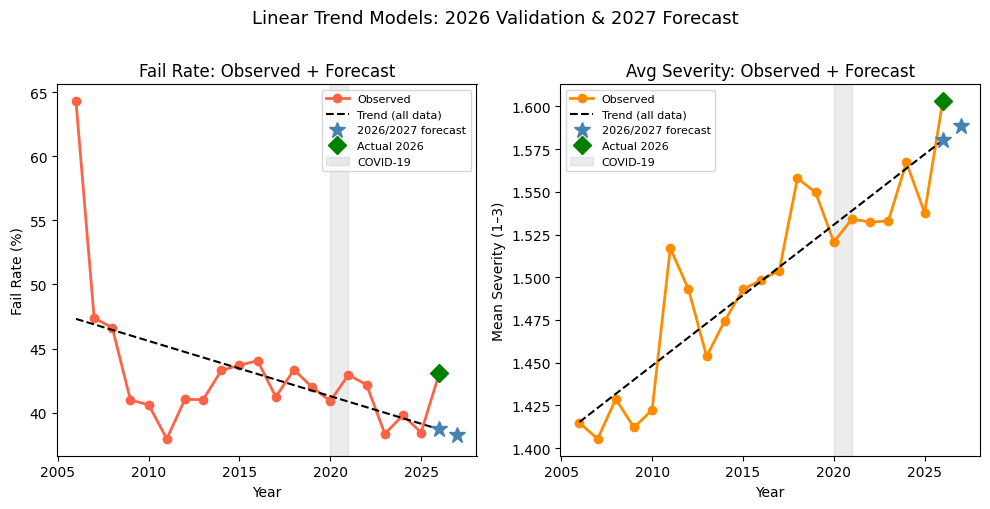

In [96]:
# Refit on ALL data to forecast 2027
slope_full, intercept_full, _, _, _ = stats.linregress(
    yearly_fail['year'], yearly_fail['fail_rate']
)
slope_sev_full, intercept_sev_full, _, _, _ = stats.linregress(
    yearly_severity['year'], yearly_severity['mean_severity']
)

pred_fail_2027 = intercept_full + slope_full * 2027
pred_sev_2027  = intercept_sev_full + slope_sev_full * 2027

print(f"\n=== 2027 Forecast (model trained on ALL data) ===")
print(f"Predicted fail rate 2027:     {pred_fail_2027 * 100:.2f}%")
print(f"Predicted avg severity 2027:  {pred_sev_2027:.4f}")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
future_years = pd.Series([2026, 2027])

# Fail rate panel
years_all = yearly_fail['year']
ax1.plot(years_all, yearly_fail['fail_rate'] * 100,
         marker='o', color='tomato', linewidth=2, label='Observed')
ax1.plot(years_all, (intercept_full + slope_full * years_all) * 100,
         '--', color='black', linewidth=1.5, label='Trend (all data)')
ax1.plot(future_years, (intercept_full + slope_full * future_years) * 100,
    marker='*', markersize=12, color='steelblue', linestyle='none', label='2026/2027 forecast')
if len(test_fail) > 0:
    ax1.plot(2026, actual_fail_2026 * 100, marker='D', markersize=9,
             color='green', linestyle='none', label='Actual 2026')
ax1.axvspan(2020, 2021, alpha=0.15, color='gray', label='COVID-19')
ax1.set_title('Fail Rate: Observed + Forecast', fontsize=12)
ax1.set_xlabel('Year')
ax1.set_ylabel('Fail Rate (%)')
ax1.legend(fontsize=8)

# Severity panel
years_sev_all = yearly_severity['year']
ax2.plot(years_sev_all, yearly_severity['mean_severity'],
         marker='o', color='darkorange', linewidth=2, label='Observed')
ax2.plot(years_sev_all, intercept_sev_full + slope_sev_full * years_sev_all,
         '--', color='black', linewidth=1.5, label='Trend (all data)')
ax2.plot(future_years, intercept_sev_full + slope_sev_full * future_years,
    marker='*', markersize=12, color='steelblue', linestyle='none', label='2026/2027 forecast')
if len(test_sev) > 0 and actual_sev_2026 is not None:
    ax2.plot(2026, actual_sev_2026, marker='D', markersize=9,
             color='green', linestyle='none', label='Actual 2026')
ax2.axvspan(2020, 2021, alpha=0.15, color='gray', label='COVID-19')
ax2.set_title('Avg Severity: Observed + Forecast', fontsize=12)
ax2.set_xlabel('Year')
ax2.set_ylabel('Mean Severity (1–3)')
ax2.legend(fontsize=8)

plt.suptitle('Linear Trend Models: 2026 Validation & 2027 Forecast', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Neighborhoods with data: 18
Neighborhoods without data: 7


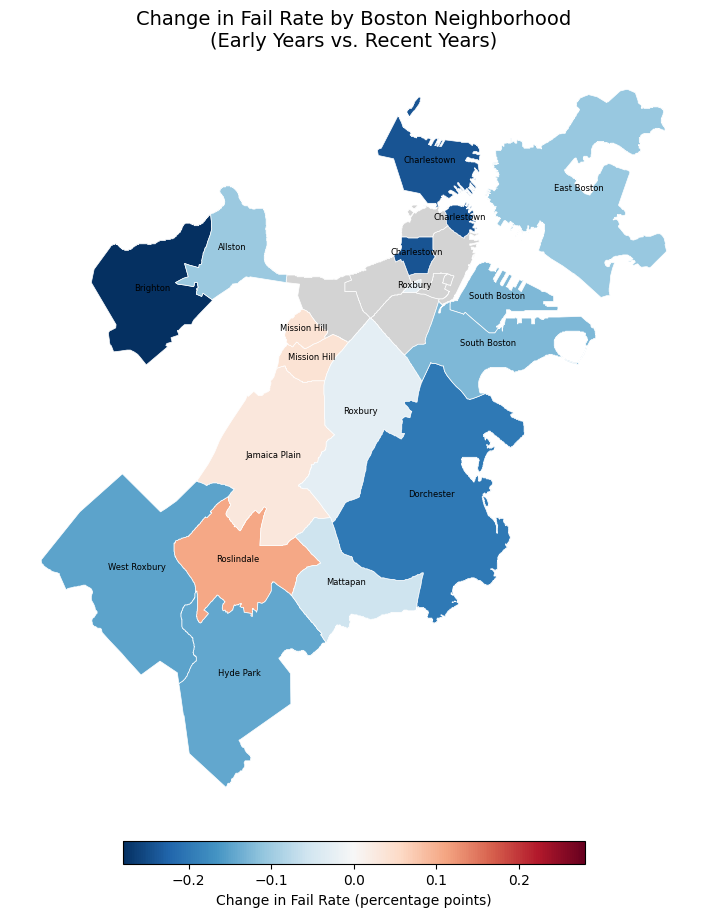

In [93]:
import urllib.request
import geopandas as gpd

urllib.request.urlretrieve(
    'https://bostonopendata-boston.opendata.arcgis.com/datasets/boston::boston-neighborhoods.geojson?outSR=%7B%22latestWkid%22%3A3857%2C%22wkid%22%3A102100%7D&where=1%3D1&outFields=*',
    'Boston_Neighborhoods.geojson'
)

neighborhoods_gdf = gpd.read_file('Boston_Neighborhoods.geojson')
neighborhoods_gdf['Name'] = neighborhoods_gdf['Name'].str.upper().str.strip()

# Fix shapefile names to match your city column
name_fixes = {
    'SOUTH BOSTON WATERFRONT': 'SOUTH BOSTON',
    'LEATHER DISTRICT':        'FINANCIAL DISTRICT',
    'LONGWOOD':                'MISSION HILL',
    'BAY VILLAGE':             'ROXBURY',
    'BEACON HILL':             'CHARLESTOWN',
    'NORTH END':               'CHARLESTOWN',
}
neighborhoods_gdf['Name'] = neighborhoods_gdf['Name'].replace(name_fixes)

# Recompute change_df excluding BOSTON catch-all and low-count neighborhoods
valid_cities = city_counts[(city_counts >= 200) & (city_counts.index != 'BOSTON')].index
neighborhood_fail_filtered = neighborhood_fail[neighborhood_fail['city'].isin(valid_cities)].copy()

early_years = sorted(analysis_df['year'].unique())[:3]
late_years  = sorted(analysis_df['year'].unique())[-3:]

early = neighborhood_fail_filtered[neighborhood_fail_filtered['year'].isin(early_years)].groupby('city')['fail_rate'].mean()
late  = neighborhood_fail_filtered[neighborhood_fail_filtered['year'].isin(late_years)].groupby('city')['fail_rate'].mean()

change_df_map = pd.DataFrame({
    'early_fail_rate': early,
    'late_fail_rate':  late
}).dropna()
change_df_map['change'] = change_df_map['late_fail_rate'] - change_df_map['early_fail_rate']

# Merge onto geodataframe
change_reset = change_df_map.reset_index()
merged = neighborhoods_gdf.merge(change_reset, left_on='Name', right_on='city', how='left')

print("Neighborhoods with data:", merged['change'].notna().sum())
print("Neighborhoods without data:", merged['change'].isna().sum())

# Plot
fig, ax = plt.subplots(figsize=(8, 10))

merged[merged['change'].isna()].plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5)

vmax = merged['change'].abs().max()
merged[merged['change'].notna()].plot(
    column='change',
    ax=ax,
    cmap='RdBu_r',
    vmin=-vmax,
    vmax=vmax,
    edgecolor='white',
    linewidth=0.5,
    legend=True,
    legend_kwds={
        'label': 'Change in Fail Rate (percentage points)',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02
    }
)

for _, row in merged[merged['change'].notna()].iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row['Name'].title(),
        xy=(centroid.x, centroid.y),
        ha='center', fontsize=6, color='black'
    )

ax.set_title('Change in Fail Rate by Boston Neighborhood\n(Early Years vs. Recent Years)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

In [88]:
# Which neighborhoods are gray and why?
shapefile_names = set(neighborhoods_gdf['Name'].str.upper().str.strip())
your_names = set(change_df.index.str.upper().str.strip())

print("In shapefile but missing from your change_df:")
print(shapefile_names - your_names)

print("\nNeighborhoods you dropped for low counts (<50 inspections):")
low_count = city_counts[city_counts < 50]
print(low_count)

print(analysis_df['city'].value_counts())

In shapefile but missing from your change_df:
{'NORTH END', 'SOUTH BOSTON WATERFRONT', 'DOWNTOWN', 'CHINATOWN', 'LEATHER DISTRICT', 'LONGWOOD', 'SOUTH END', 'WEST END', 'FENWAY', 'BAY VILLAGE', 'BACK BAY', 'BEACON HILL'}

Neighborhoods you dropped for low counts (<50 inspections):
city
BACK BAY     10
CHINATOWN     5
FENWAY       36
SOUTH END     8
WEST END      7
Name: failed, dtype: int64
city
BOSTON                73774
DORCHESTER            17685
EAST BOSTON           10104
ROXBURY                9835
ALLSTON                5591
BRIGHTON               5299
JAMAICA PLAIN          5157
SOUTH BOSTON           4641
ROSLINDALE             3716
WEST ROXBURY           3270
CHARLESTOWN            2613
HYDE PARK              2513
MATTAPAN               2245
MISSION HILL           1922
CHESTNUT HILL           135
FINANCIAL DISTRICT      109
FENWAY                   36
BACK BAY                 10
SOUTH END                 8
WEST END                  7
CHINATOWN                 5
Name: count, 

In [97]:
# To complete the poster info needed:

sig = results_df[results_df['p_value'] < 0.05]
print("Improving (sig):", (sig['slope'] < 0).sum())
print("Worsening (sig):", (sig['slope'] > 0).sum())

print(f"Predicted fail rate 2026: {pred_fail_2026*100:.2f}%")
print(f"Actual fail rate 2026:    {actual_fail_2026*100:.2f}%")
print(f"Error:                    {(pred_fail_2026 - actual_fail_2026)*100:.2f} pp")
print(f"Predicted fail rate 2027: {pred_fail_2027*100:.2f}%")
print(f"Predicted severity 2027:  {pred_sev_2027:.4f}")

print(f"Actual severity 2026: {actual_sev_2026:.4f}")
print(f"Predicted severity 2026: {pred_sev_2026:.4f}")
print(f"Error: {pred_sev_2026 - actual_sev_2026:.4f}")

Improving (sig): 3
Worsening (sig): 1
Predicted fail rate 2026: 37.77%
Actual fail rate 2026:    43.07%
Error:                    -5.30 pp
Predicted fail rate 2027: 38.28%
Predicted severity 2027:  1.5884
Actual severity 2026: 1.6030
Predicted severity 2026: 1.5752
Error: -0.0278
